In [1]:
!git clone https://github.com/Azure2212/3D_PDB.git

Cloning into '3D_PDB'...
remote: Enumerating objects: 544, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 544 (delta 0), reused 3 (delta 0), pack-reused 540 (from 1)
Receiving objects: 100% (544/544), 477.76 MiB | 31.95 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Updating files: 100% (462/462), done.


In [2]:
import os 
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from PIL import Image
configs = {
    "structure_path": "/kaggle/working/3D_PDB",
    "protein_path": "/kaggle/working/3D_PDB/HDF",
    "image_size": 224,
    "n_channels": 3,
    "n_classes": 4,
    "model": "ConvNeXt", 
    "lr": 1e-03,
    "min_lr": 1e-07,
    "weighted_loss": 0,
    "device": "cuda:0",
    "batch_size": 32,
    "num_workers": 2,
    "earlyStopping": 1000,
    "max_epoch_num": 100,
    "plateau_patience": 10,
    "steplr": 50,
    "optimizer_chose":"RAdam",
    "lr_scheduler":"CosineAnnealingLR",
    "project_name": "ProteinClassification",
    "wandb_api_key": "Qbo3kwrtRENVIG8hqrfSVpYn5dc_mvxp0fRvc4DE",
    "rs_dir":"/kaggle/working/PDBRSTuan.pt",
    "name_run_wandb":"Tuan_dep_trai_ne",
    "test_image_path": "/kaggle/working/3D_PDB/testingDataFromProfessorSu"
}

In [3]:
class_names = {}
nameProtein = '4P7F'
image_path = f'{configs['protein_path']}/{nameProtein}.hdf'

with h5py.File(image_path, "r") as hdf_file:
    images_group = hdf_file["MDF/images"]
    keys = sorted(images_group.keys(), key=lambda x: int(x))
    stack_list = [images_group[k]["image"][:] for k in keys]
    stack = np.stack(stack_list, axis=0)

print(len(stack))
print(stack.shape)
# raise Exception("stop")

50


<h1>1. Origin 2D image</h1>

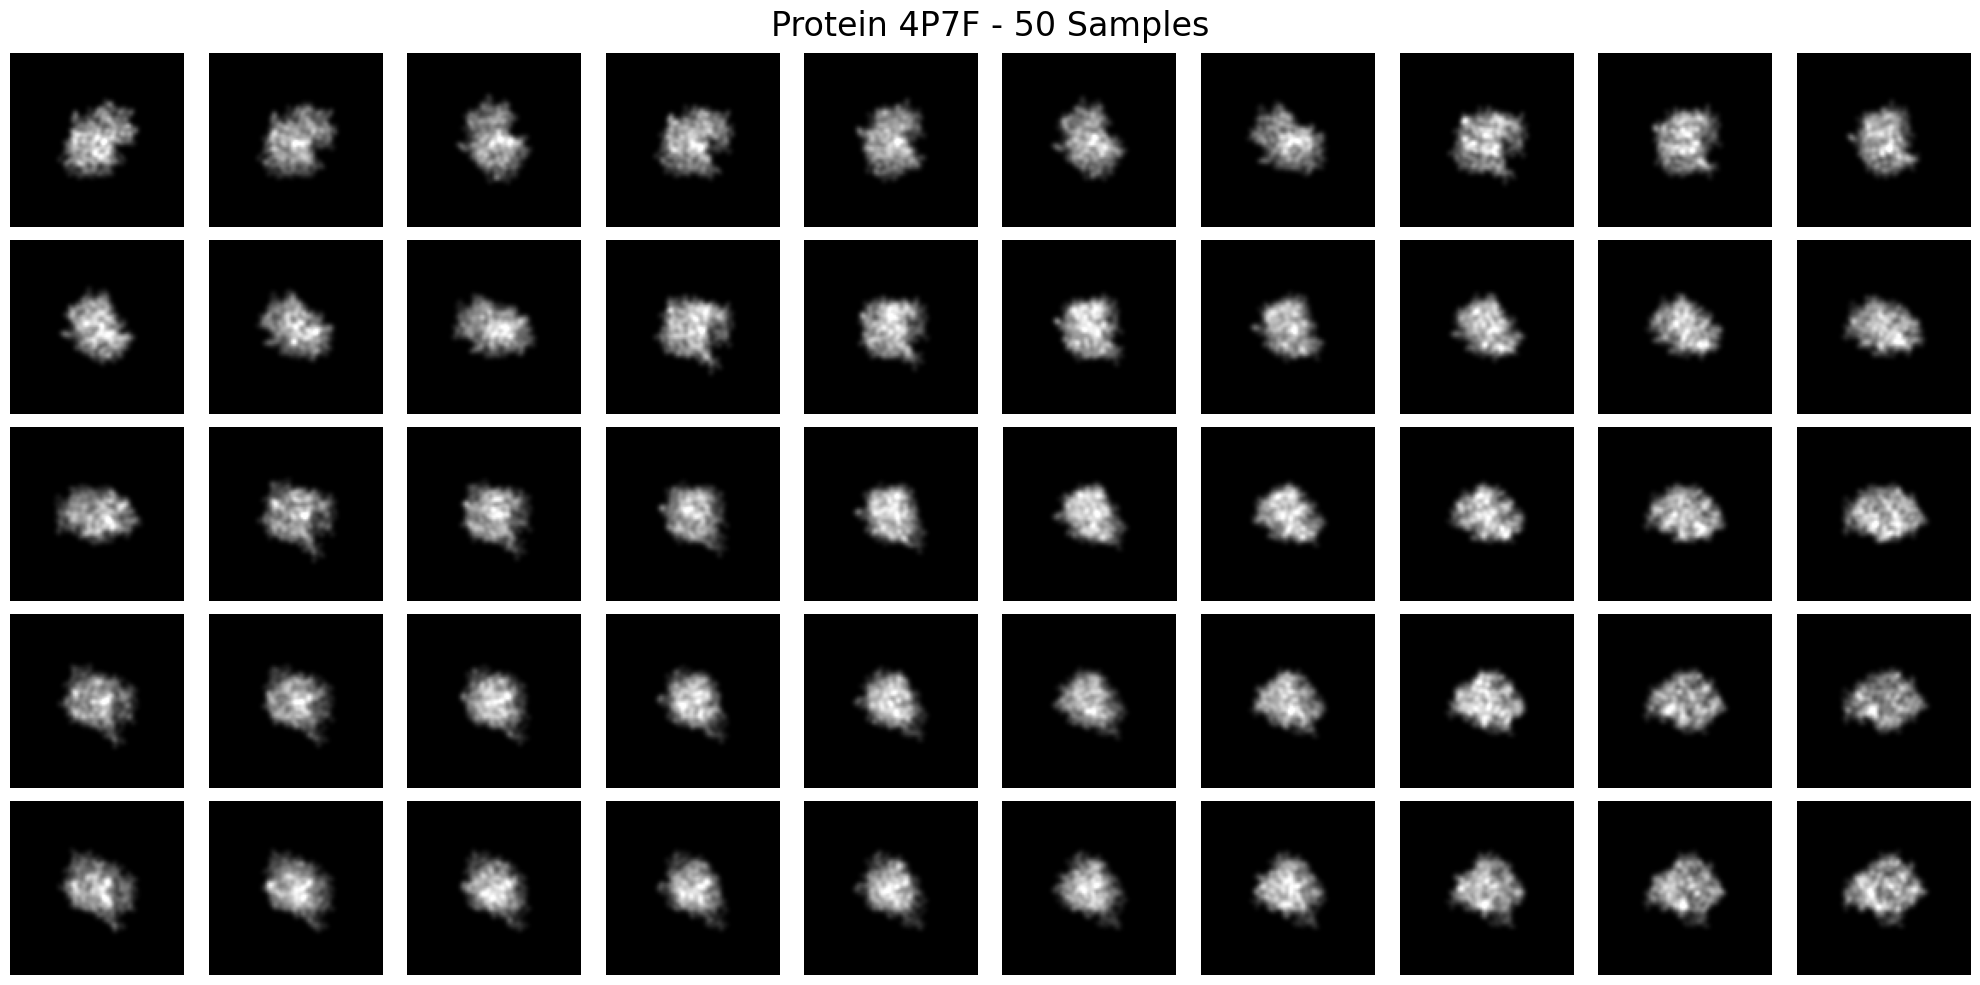

In [4]:
# print(allProteinPath[0].shape)

# Assuming allProteinPath[0] has shape (50, 324, 324)
index = 0
images = stack

fig, axes = plt.subplots(5, 10, figsize=(20, 10))

for i in range(50):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(images[i], cmap='gray')
    axes[row, col].axis('off')

fig.suptitle(f"Protein {nameProtein} - 50 Samples", fontsize=24)
plt.tight_layout()
plt.show()


<h1>2. Transform 2D image</h1>
<h1>2.1 Training Transform</h1>

In [16]:
stack_uint8 = (stack * 255).astype(np.uint8)

train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=360, interpolation=InterpolationMode.BILINEAR, fill=0),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x + 0.02 * torch.randn_like(x)).clamp(0.0, 1.0)),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Apply transforms to all 50 images
transformed_images = []
for img_array in stack_uint8:
    pil_img = Image.fromarray(img_array)  
    tensor_img = train_tf(pil_img)        
    transformed_images.append(tensor_img)

transformed_stack = torch.stack(transformed_images)
print(transformed_stack.shape) 

torch.Size([50, 3, 224, 224])


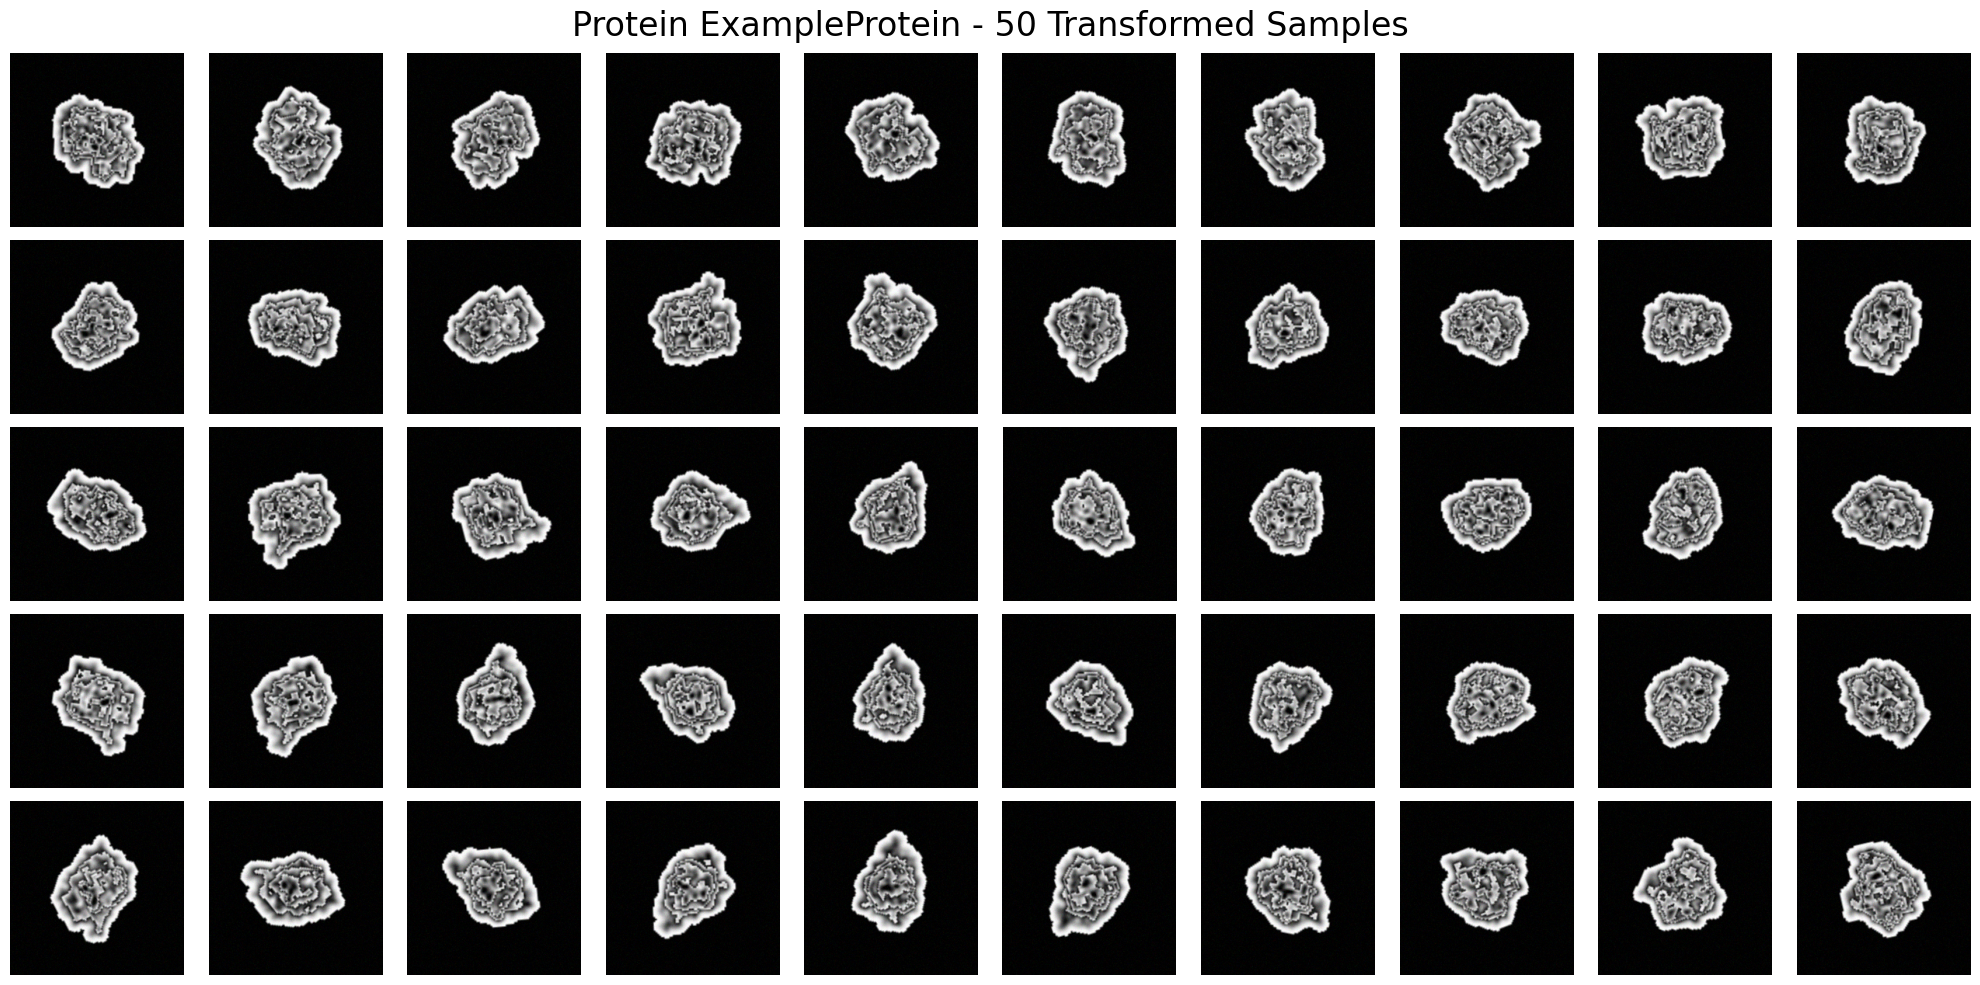

In [17]:
# Denormalize function
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(tensor):
    return (tensor * imagenet_std + imagenet_mean).clamp(0,1)

plot_images = [denormalize(img).permute(1,2,0).numpy() for img in transformed_stack]

nameProtein = "ExampleProtein"

fig, axes = plt.subplots(5, 10, figsize=(20, 10))

for i in range(50):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(plot_images[i])
    axes[row, col].axis('off')

fig.suptitle(f"Protein {nameProtein} - 50 Transformed Samples", fontsize=24)
plt.tight_layout()
plt.show()

<h1>2.1 Validation Transform</h1>

In [18]:
stack_uint8 = (stack * 255).astype(np.uint8)

# Define your transform (you already have this)
val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Apply transforms to all 50 images
transformed_images = []
for img_array in stack_uint8:
    pil_img = Image.fromarray(img_array)  
    tensor_img = train_tf(pil_img)        
    transformed_images.append(tensor_img)

transformed_stack = torch.stack(transformed_images)
print(transformed_stack.shape) 

torch.Size([50, 3, 224, 224])


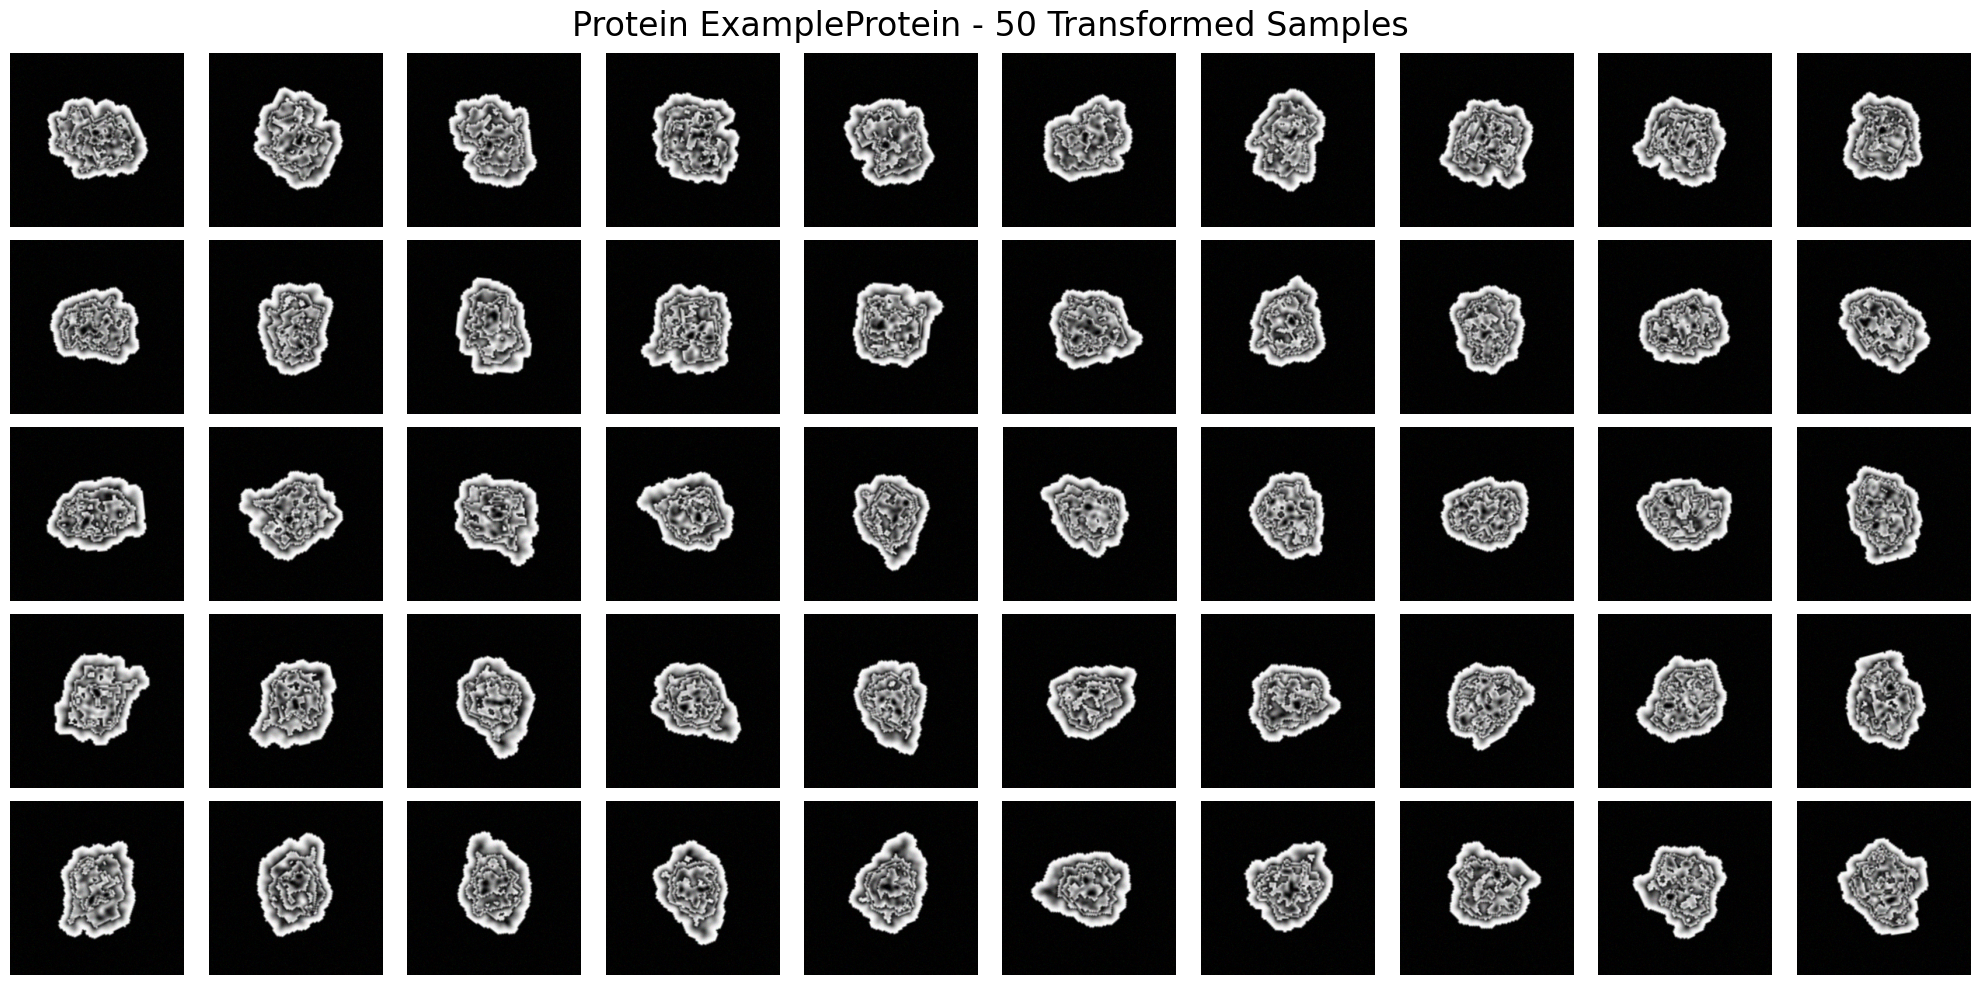

In [19]:
# Denormalize function
imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

def denormalize(tensor):
    return (tensor * imagenet_std + imagenet_mean).clamp(0,1)

# Prepare images for plotting: convert to numpy H×W×C
plot_images = [denormalize(img).permute(1,2,0).numpy() for img in transformed_stack]

nameProtein = "ExampleProtein"

fig, axes = plt.subplots(5, 10, figsize=(20, 10))

for i in range(50):
    row = i // 10
    col = i % 10
    axes[row, col].imshow(plot_images[i])
    axes[row, col].axis('off')

fig.suptitle(f"Protein {nameProtein} - 50 Transformed Samples", fontsize=24)
plt.tight_layout()
plt.show()